# Change Point Detection

In this notebook, I create standard error estimates using bootstrapping, and use the estimates to conduct change point detection analysis (CUSUM and EWMA-residual).

In [1]:
# Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

"/Users/jananidhileepan/Desktop/Don't. Even./University/Imperial College London/Year 2/Dissertation/GitHub/fairness_smoke_alarm/src"

In [3]:
from fairness_metrics import (
    dict_references,
    get_bin_edges,
    dem_parity_total,
    eq_odds_total,
    calibration_total,
    unfairness_score
)

## 1. Standard Error Estimation using Bootstrapping

In [4]:
hmda_pred = pd.read_csv("../data/processed/hmda_with_predictions.csv", index_col=0)
hmda_2007_pred = hmda_pred[hmda_pred["year"] == 2007].copy()

In [5]:
bin_edges = get_bin_edges(hmda_2007_pred)

def check_categories_present(df, attribute):
    """Raise if a bootstrap resample dropped a category, which would silently
    shift the positional indexing in dem_parity_calc/eq_odds_calc."""
    expected = sorted(hmda_2007_pred[attribute].dropna().unique())
    present = sorted(df[attribute].dropna().unique())
    if present != expected:
        missing = set(expected) - set(present)
        raise ValueError(f"Resample missing categories in '{attribute}': {missing}")

def bootstrap_fairness_metrics(df, bin_edges, n_bootstrap=200, random_state=0):
    """
    Bootstrap DP/EO/CAL on df.
    Returns a DataFrame with one row per resample, columns are DP/EO/CAL.
    """
    n = len(df)
    rng = np.random.default_rng(random_state)
    records = []

    for i in range(n_bootstrap):
        # Draw n row-indices with replacement; every column travels together per row
        idx = rng.integers(0, n, size=n)
        resample = df.iloc[idx]

        # Guard against a resample silently dropping a subgroup category
        for attribute in ["race", "sex", "ethnicity"]:
            check_categories_present(resample, attribute)

        dp = dem_parity_total(resample)
        eo = eq_odds_total(resample)
        cal = calibration_total(resample, bin_edges)

        records.append({"DP": dp, "EO": eo, "CAL": cal})

    return pd.DataFrame(records)

# Run it
# boot_df = bootstrap_fairness_metrics(hmda_2007_pred, bin_edges, n_bootstrap=200, random_state=0)
# boot_df.to_csv("../data/processed/bootstrap.csv")

In [6]:
# Function to estimate standard deviation
def sigma_hat(boot_df, alpha, beta, gamma):
    composite = alpha * boot_df["DP"] + beta * boot_df["EO"] + gamma * boot_df["CAL"]
    return composite.std()

## 2. Change Point Detection - CUSUM

### A. Cumulative Sum (CUSUM)

In [7]:
# Get data
boot_df = pd.read_csv("../data/processed/bootstrap.csv", index_col = 0)
df_fairness = pd.read_csv("../data/processed/fairness_numbers.csv", index_col = 0)

print(df_fairness)

            DP        EO       CAL
2007  0.114667  0.101167  0.125858
2008  0.117333  0.097000  0.112692
2009  0.067667  0.062667  0.189290
2010  0.062000  0.060500  0.222238
2011  0.069000  0.066500  0.226680
2012  0.081667  0.080333  0.259031
2013  0.080333  0.082333  0.253610
2014  0.072000  0.070500  0.232353
2015  0.075333  0.069167  0.240145
2016  0.072000  0.069000  0.226187
2017  0.078333  0.073500  0.262821


In [8]:
# Class that defines the CUSUM alarm

class CUSUMDetector:
    def __init__(self, series, sigma_hat, k=0.5, h=4.77, baseline_year=2007):
        """
        series: pandas Series indexed by year, including baseline_year
        sigma_hat: standard deviation to standardize with
        onset year: last good year before the alarm rang
        """
        self.series = series
        self.baseline_year = baseline_year
        self.sigma_hat = sigma_hat
        self.k = k
        self.h = h

        self.mu_0 = self.series.loc[baseline_year]
        self.years = self.series.index.drop(baseline_year)

        # Populated by run()
        self.alarm = None
        self.onset_year = None
        self.C_plus = None

    def run(self):
        alarm = pd.Series(0, index=self.years)
        onset_year = pd.Series(None, index=self.years, dtype="object")
        C_plus_trajectory = pd.Series(0.0, index=self.years)

        C_plus_t = 0
        N_plus = 0

        for year in self.years:
            x_t = self.series.loc[year]
            y_t = (x_t - self.mu_0) / self.sigma_hat
            C_plus_t = max(0, y_t - self.k + C_plus_t)
            C_plus_trajectory.loc[year] = C_plus_t

            N_plus = 0 if C_plus_t == 0 else N_plus + 1

            if C_plus_t > self.h:
                alarm.loc[year] = 1
                onset_year.loc[year] = year - N_plus

        self.alarm = alarm
        self.onset_year = onset_year
        self.C_plus = C_plus_trajectory
        return alarm, onset_year, C_plus_trajectory

#### Example: alpha = 1/3, beta = 1/3, gamma = 1/3

In [9]:
composite = unfairness_score(df_fairness)  # full series, 2007-2017
se = sigma_hat(boot_df, alpha = 1/3, beta = 1/3, gamma = 1/3)

det = CUSUMDetector(composite, sigma_hat=se)
det.run()
det.alarm # Series indexed by year
det.onset_year
det.C_plus # Trajectory

2008      0.000000
2009      0.000000
2010      1.565666
2011     14.954260
2012     68.236245
2013    118.295702
2014    140.275122
2015    168.892025
2016    185.674948
2017    234.634423
dtype: float64

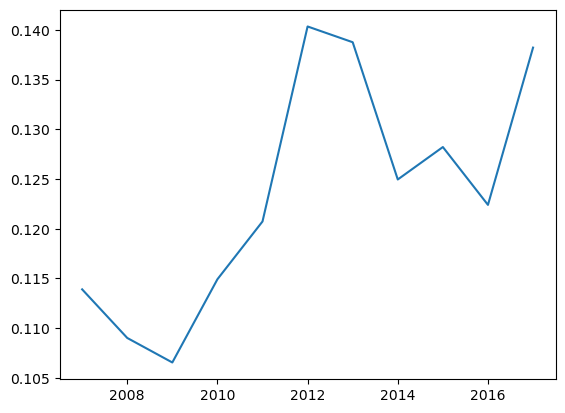

In [10]:
# Visual inspection of unfairness score on the composite weighting

ys = unfairness_score(df_fairness)  # Series indexed 2007-2017
plt.plot(ys.index, ys.values)
plt.show()

### B. Referee CUSUM

In [11]:
# Function that defines the "referee", i.e. the ground-truth proxy for fairness

def referee_cusum(df_fairness, boot_df, k=0.5, h=4.77, baseline_year=2007):
    """
    Runs CUSUM independently on DP, EO, and CAL (each with its own mu_0 and
    sigma_hat), then combines via OR: referee alarms in year t if ANY of the
    three individual metrics alarm in year t.
    """
    detectors = {}

    for metric in ["DP", "EO", "CAL"]:
        series = df_fairness[metric]
        se = boot_df[metric].std()  # marginal SE for this metric alone

        det = CUSUMDetector(series, sigma_hat=se, k=k, h=h, baseline_year=baseline_year)
        det.run()
        detectors[metric] = det

    # OR combination: referee alarms if any individual detector alarms
    alarm_matrix = pd.DataFrame({
        metric: detectors[metric].alarm for metric in detectors
    })
    referee_alarm = (alarm_matrix.sum(axis=1) > 0).astype(int)

    return referee_alarm, detectors


# Usage
referee_alarm, individual_detectors = referee_cusum(df_fairness, boot_df)
print(referee_alarm)

2008    0
2009    1
2010    1
2011    1
2012    1
2013    1
2014    1
2015    1
2016    1
2017    1
dtype: int64


### C. Compare alarm to referee

In [12]:
def miss_rate_for_weighting(alpha, beta, gamma, df_fairness, boot_df, referee_alarm,
                              k=0.5, h=4.77, baseline_year=2007):
    composite = unfairness_score(df_fairness, alpha, beta, gamma)
    se = sigma_hat(boot_df, alpha, beta, gamma)

    det = CUSUMDetector(composite, sigma_hat=se, k=k, h=h, baseline_year=baseline_year)
    det.run()

    misses = (referee_alarm == 1) & (det.alarm == 0)
    n_flagged = (referee_alarm == 1).sum()

    if n_flagged == 0:
        miss_rate = None
    else:
        miss_rate = misses.sum() / n_flagged

    return {
        "alpha": alpha, "beta": beta, "gamma": gamma,
        "miss_rate": miss_rate,
        "any_miss": bool(misses.any()),
        "composite_ever_alarmed": bool((det.alarm == 1).any()),
        "referee_flagged_years": n_flagged,
    }

In [13]:
# View the miss rate for the composite weighting example

result = miss_rate_for_weighting(1/3, 1/3, 1/3, df_fairness, boot_df, referee_alarm)
print(result)

{'alpha': 0.3333333333333333, 'beta': 0.3333333333333333, 'gamma': 0.3333333333333333, 'miss_rate': 0.2222222222222222, 'any_miss': True, 'composite_ever_alarmed': True, 'referee_flagged_years': 9}


In [14]:
# Compare the referee vs. ground truth

comparison = pd.DataFrame({
    "referee_alarm": referee_alarm,
    "composite_alarm": det.alarm,
    "C_plus": det.C_plus,
    "h": det.h,
})

print(comparison)

      referee_alarm  composite_alarm      C_plus     h
2008              0                0    0.000000  4.77
2009              1                0    0.000000  4.77
2010              1                0    1.565666  4.77
2011              1                1   14.954260  4.77
2012              1                1   68.236245  4.77
2013              1                1  118.295702  4.77
2014              1                1  140.275122  4.77
2015              1                1  168.892025  4.77
2016              1                1  185.674948  4.77
2017              1                1  234.634423  4.77


## 3. Change Point Detection - EWMA

### A. Exponentially Weighted Moving Average (EWMA)

In [15]:
class EWMAResidualDetector:
    def __init__(self, series, sigma_hat, lam=0.4, L=3, baseline_year=2007):
        """
        series: pandas Series indexed by year, including baseline_year
        sigma_hat: bootstrap SD of the composite metric (the same one CUSUM uses)
        lam: EWMA smoothing parameter in (0, 1); weight on the newest year
        L: control-limit multiplier (L=3 -> ARL0 ~ 370, matching the CUSUM)
        """
        self.series = series
        self.baseline_year = baseline_year
        self.sigma_hat = sigma_hat
        self.lam = lam
        self.L = L

        # The 2007 value is the forecast anchor (z_0): the first year is predicted
        # from baseline, then the forecast adapts as it walks forward.
        self.z0 = self.series.loc[baseline_year]
        self.years = self.series.index.drop(baseline_year)

        # Prediction errors vary than the metric, so scale sigma_hat up.
        # sigma_e = sigma_hat * sqrt(2 / (2 - lam)).
        self.sigma_e = self.sigma_hat * np.sqrt(2 / (2 - self.lam))

        # Populated by run()
        self.alarm = None
        self.residuals = None
        self.forecast = None

    def run(self):
        alarm = pd.Series(0, index=self.years)
        residuals = pd.Series(0.0, index=self.years)
        forecast = pd.Series(0.0, index=self.years)

        z_prev = self.z0  # forecast for the first monitored year is the 2007 anchor

        for year in self.years:
            x_t = self.series.loc[year]

            # one-step residual: actual minus what the smoothed trend predicted
            e_t = x_t - z_prev
            residuals.loc[year] = e_t
            forecast.loc[year] = z_prev

            # one-sided upper alarm: metric running above its own recent trend
            if e_t > self.L * self.sigma_e:
                alarm.loc[year] = 1

            # update the smoothed forecast for next year
            z_prev = self.lam * x_t + (1 - self.lam) * z_prev

        self.alarm = alarm
        self.residuals = residuals
        self.forecast = forecast
        return alarm, residuals, forecast

In [ ]:
ewma_alarm = EWMAResidualDetector(composite, sigma_hat=se)
ewma_alarm.run()
ewma_alarm.alarm # Series indexed by year
ewma_alarm.residuals
ewma_alarm.forecast # Trajectory